# Heuristiques d'ouverture — Can't Stop

Ce notebook implémente et compare plusieurs heuristiques pour le jeu Can't Stop dans un contexte d'**ouverture de colonnes** (1 joueur, objectif : compléter 3 colonnes en un minimum de tours).

Les heuristiques sont benchmarkées sur 5000 simulations chacune. La métrique principale est le **nombre de tours pour compléter 3 colonnes** (plus petit = meilleur).

## 1. Initialisation

Imports, constantes du jeu (hauteurs des colonnes `Ns`, probabilités `PROB_COL`) et fonctions utilitaires communes à toutes les heuristiques (`get_pairings`, `action_is_legal`, `apply_action`, `bank_progress`).

In [1]:
import numpy as np
import random as rd
from itertools import product as iproduct
from collections import Counter

In [2]:
MARKER_PENALTY_H2 = 0.15
N_SIMULATIONS = 5000   

COLUMNS = range(2, 13)

Ns = {
    2: 3, 3: 5, 4: 7, 5: 9, 6: 11,
    7: 13,
    8: 11, 9: 9, 10: 7, 11: 5, 12: 3
}

In [3]:
def _compute_prob_col(target):
    count = 0
    for roll in iproduct(range(1, 7), repeat=4):
        d1, d2, d3, d4 = roll
        sums = {d1+d2, d3+d4, d1+d3, d2+d4, d1+d4, d2+d3}
        if target in sums:
            count += 1
    return count / 1296

PROB_COL = {c: _compute_prob_col(c) for c in COLUMNS}
ALL_ROLLS = list(iproduct(range(1, 7), repeat=4))

In [4]:
def get_pairings(roll):
    d1, d2, d3, d4 = roll
    pairings = [
        tuple(sorted((d1+d2, d3+d4))),
        tuple(sorted((d1+d3, d2+d4))),
        tuple(sorted((d1+d4, d2+d3))),
    ]
    seen = set()
    unique = []
    for p in pairings:
        if p not in seen:
            seen.add(p)
            unique.append(p)
    return unique


def action_is_legal(action, progress, temp_progress):
    new_cols = set()
    has_progress = False
    for s in action:
        if progress[s] + temp_progress.get(s, 0) >= Ns[s]:
            continue  # colonne bloquée : on l'ignore, pas illégal
        has_progress = True
        if s not in temp_progress:
            new_cols.add(s)
    if not has_progress:
        return False  # les DEUX colonnes bloquées → bust
    return len(temp_progress) + len(new_cols) <= 3


def apply_action(action, progress, temp_progress):
    new_temp = temp_progress.copy()
    for s in action:
        if progress[s] + new_temp.get(s, 0) < Ns[s]:
            new_temp[s] = new_temp.get(s, 0) + 1
    return new_temp


def bank_progress(progress, temp_progress):
    new_progress = progress.copy()
    for s, inc in temp_progress.items():
        new_progress[s] = min(new_progress[s] + inc, Ns[s])
    return new_progress


def nb_won_columns(progress):
    return sum(progress[s] >= Ns[s] for s in COLUMNS)

## 2. Heuristiques

### 2.0 Baselines naïves

Deux baselines sans logique probabiliste, servant de référence basse dans le benchmark.

**Random + Stop@4** : pairing aléatoire parmi les actions légales, arrêt systématique après 4 lancers par tour.

**Score@3** : pairing choisi par score pondéré favorisant les colonnes centrales (score = `6 - |7 - s|`) avec bonus si colonne proche du sommet, arrêt systématique après 3 lancers. Correspond à `make_max_steps_stop_k(3)` du simulateur complet.

### 2.1 H1 — Minimiser les ouvertures

Stratégie conservatrice : si une action légale n'ouvre pas de nouvelle colonne, elle est préférée. Sinon, on choisit la colonne à ouvrir selon le ratio `p_c / cases_restantes`. Arrêt après 3 lancers.

In [5]:
# ============================================================
# HEURISTIQUE : Random + Stop@4
# ============================================================
# Pairing aléatoire parmi les actions légales.
# Arrêt systématique après 4 lancers dans le tour.

import random as rd

def heuristic_random_stop4(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    """
    Baseline naïve : choix de pairing aléatoire, stop après 4 lancers.
    """
    action = rd.choice(legal_actions)
    stop = (turn_roll_count >= 4)
    return action, stop

In [6]:
# ============================================================
# HEURISTIQUE : Score@3
# ============================================================
# Choix du pairing par score pondéré (colonnes centrales favorisées,
# bonus si colonne proche du sommet, léger malus pour nouvelle colonne).
# Arrêt systématique après 3 lancers dans le tour.

def _score_central(action, progress, temp_progress):
    """Score favoring central columns and nearly-finished columns."""
    val = 0
    for s in action:
        val += 6 - abs(7 - s)
        current_pos = progress[s] + temp_progress.get(s, 0)
        remaining = Ns[s] - current_pos
        if remaining <= 2:
            val += 3
        if s not in temp_progress:
            val -= 1
    return val


def heuristic_score_stop3(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    """
    Score@3 : meilleur pairing par score pondéré, stop après 3 lancers.
    Correspond à make_max_steps_stop_k(3) du simulateur original.
    """
    action = max(legal_actions, key=lambda a: _score_central(a, progress, temp_progress))
    stop = (turn_roll_count >= 3)
    return action, stop

In [7]:
# ============================================================
# H1 — MINIMISER OUVERTURES
# ============================================================

def score_h1_no_open(action, progress, temp_progress):
    score = 0
    for s in action:
        score += 6 - abs(7 - s)
        remaining = Ns[s] - progress[s] - temp_progress.get(s, 0)
        if remaining <= 2:
            score += 3
    return score


def choose_action_h1(progress, temp_progress, legal_actions):
    no_open = [a for a in legal_actions if all(s in temp_progress for s in a)]
    if no_open:
        return max(no_open, key=lambda a: score_h1_no_open(a, progress, temp_progress))

    def open_value(a):
        val = 0
        for s in set(a):
            if s not in temp_progress:
                remaining = max(Ns[s] - progress[s] - temp_progress.get(s, 0), 1)
                val += PROB_COL[s] / remaining
        return val

    return max(legal_actions, key=open_value)


def heuristic_h1(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_h1(progress, temp_progress, legal_actions)
    return action, (turn_roll_count >= 3)

### 2.2 H2 — Score probabiliste (`p_c / restants`)

Pour chaque action légale, on calcule un score = somme des `PROB_COL[s] / cases_restantes` sur les colonnes avancées, avec un malus (`MARKER_PENALTY_H2 = 0.15`) pour chaque nouvelle colonne ouverte.

Arrêt après 3 lancers (critère fixe — toute l'intelligence de H2 est dans le choix du pairing).

In [8]:
# ============================================================
# H2 — p_c / restants
# ============================================================

def col_value(s, progress, temp_progress):
    current = progress[s] + temp_progress.get(s, 0)
    remaining = max(Ns[s] - current, 1)
    return PROB_COL[s] / remaining


def score_h2(action, progress, temp_progress):
    score = 0
    for s, mult in Counter(action).items():
        score += mult * col_value(s, progress, temp_progress)
        if s not in temp_progress:
            score -= MARKER_PENALTY_H2
    return score


def heuristic_h2(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = max(legal_actions, key=lambda a: score_h2(a, progress, temp_progress))
    return action, (turn_roll_count >= 3)

### 2.3 H3 — Minimiser la probabilité de bust

Choisit l'action qui minimise la probabilité de bust au prochain lancer (calcul exact sur les 1296 jets possibles). En cas d'égalité, départage par le score H2. Arrêt après 3 lancers.

In [9]:
# ============================================================
# H3 — MINIMISER BUST
# ============================================================

def bust_prob_after_action(action, progress, temp_progress):
    hyp = temp_progress.copy()
    for s in action:
        if progress[s] + hyp.get(s, 0) < Ns[s]:
            hyp[s] = hyp.get(s, 0) + 1

    busts = 0
    for roll in ALL_ROLLS:
        pairings = get_pairings(roll)
        if not any(action_is_legal(p, progress, hyp) for p in pairings):
            busts += 1
    return busts / 1296


def heuristic_h3(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    probs = [bust_prob_after_action(a, progress, temp_progress) for a in legal_actions]
    min_p = min(probs)
    candidates = [a for a, p in zip(legal_actions, probs) if p == min_p]
    action = max(candidates, key=lambda a: score_h2(a, progress, temp_progress))
    return action, (turn_roll_count >= 3)

### 2.4 H4 — Rule of 28 (littérature)

Heuristique issue du papier *"A Generalized Heuristic for Can't Stop"*. Le pairing est choisi par une valeur de mouvement `p_i * (6 - |7-s|) - 6 * nouveau_marqueur`. L'arrêt est déclenché quand un score de progression dépasse 28, avec des ajustements selon la parité et la hauteur des colonnes ouvertes.

In [10]:
# ============================================================
# H4 — RULE OF 28 (Version EXACTE Keller 1986)
# ============================================================

def should_stop_rule_of_28(progress, temp_progress):
    if not temp_progress:
        return False
    weights = {2:6, 3:5, 4:4, 5:3, 6:2, 7:1, 8:2, 9:3, 10:4, 11:5, 12:6}
    total = 0
    for col, inc in temp_progress.items():
        total_height = progress[col] + inc
        total += (total_height + 1) * weights[col]
    if len(temp_progress) == 3:
        cols = list(temp_progress.keys())
        if all(x % 2 == 1 for x in cols): total += 2
        if all(x % 2 == 0 for x in cols): total -= 2
        if all(x >= 7 for x in cols):     total += 4
        if all(x <= 7 for x in cols):     total += 4
    return total >= 28


def choose_action_rule_of_28(progress, temp_progress, legal_actions):
    def move_value(action):
        counts = {}
        for s in action:
            counts[s] = counts.get(s, 0) + 1
        value = 0
        for s, p_i in counts.items():
            value += p_i * (6 - abs(7 - s))
            value -= 6 * (1 if s not in temp_progress else 0)
        return value
    return max(legal_actions, key=move_value)


def heuristic_rule_of_28(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_rule_of_28(progress, temp_progress, legal_actions)
    new_temp = apply_action(action, progress, temp_progress)
    stop = should_stop_rule_of_28(progress, new_temp)
    return action, stop

### 2.5 H5 — Constant Weights (papier, corrigé)

Heuristique optimisée par algorithme génétique dans le papier. Les poids `W_MOVE` et `W_PROG` favorisent fortement les colonnes extrêmes (2 et 12).

**Correction apportée** : la version originale calculait le score d'arrêt sur `W_PROG[s] * s_i` (incrément du tour uniquement), ce qui empêchait d'atteindre le seuil 29 sur les colonnes centrales (faibles poids) → divergence massive. La version corrigée utilise `W_PROG[s] * (progress[s] + s_i)` (hauteur totale atteinte).

In [11]:
# ============================================================
# H5 — CONSTANT WEIGHTS (champion du papier)
# ============================================================

W_MOVE = {2:7, 3:0, 4:2, 5:0, 6:4, 7:3, 8:4, 9:0, 10:2, 11:0, 12:7}
W_PROG = {2:7, 3:7, 4:3, 5:2, 6:2, 7:1, 8:2, 9:2, 10:3, 11:7, 12:7}

MARKER_PENALTY_CW = 6
STOP_THRESHOLD_CW = 29

def choose_action_cw(progress, temp_progress, legal_actions):
    def move_value(action):
        value = 0
        for s in action:
            opens_new = 1 if s not in temp_progress else 0
            value += W_MOVE.get(s, 0) - MARKER_PENALTY_CW * opens_new
        return value
    return max(legal_actions, key=move_value)


def should_stop_cw(progress, temp_progress):
    if not temp_progress:
        return False
    
    value = 0
    for col, inc in temp_progress.items():
        height = progress[col] + inc
        value += W_PROG.get(col, 0) * (height + 1)
    
    if len(temp_progress) == 3:
        cols = list(temp_progress.keys())
        if all(x % 2 == 1 for x in cols): value += 7
        if all(x % 2 == 0 for x in cols): value += 1
        if all(x >= 7 for x in cols):     value += 6
        if all(x <= 7 for x in cols):     value += 5
    
    return value >= STOP_THRESHOLD_CW


def heuristic_constant_weights(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_cw(progress, temp_progress, legal_actions)
    new_temp = apply_action(action, progress, temp_progress)
    stop = should_stop_cw(progress, new_temp)
    return action, stop

### 2.6 H6 — DP-3-colonnes (lien avec la programmation dynamique)

Cette heuristique établit le lien avec la résolution exacte par programmation dynamique développée dans `3_columns_with_numba.ipynb`.

**Principe** : quand exactement 3 colonnes sont ouvertes dans le tour en cours, on résout le sous-problème DP exact sur ces 3 colonnes (`compute_V_dp3`) pour décider si s'arrêter est optimal — on s'arrête si et seulement si `gain_actuel ≥ V_dp(position courante)`. Quand moins de 3 colonnes sont ouvertes, on continue toujours (pas de sous-problème DP bien posé).

**Choix du pairing** : identique à H2 (meilleure heuristique empirique).

**Cache** : `_dp3_cache` évite de recalculer `V` pour le même triplet de colonnes et la même position sécurisée de départ — essentiel pour les performances.

Les fonctions `compute_probabilities`, `actions_from_roll`, `precompute_actions_dp3` et `compute_V_dp3` sont recopiées directement depuis `3_columns_with_numba.ipynb`.

In [31]:
# ============================================================
# FONCTIONS DP-3-COLONNES (recopiées depuis 3_columns_with_numba.ipynb)
# ============================================================

import numpy as np
from numba import njit


def compute_probabilities():
    pairs = {}
    for dice1 in range(1, 7):
        for dice2 in range(1, 7):
            for dice3 in range(1, 7):
                for dice4 in range(1, 7):
                    couples_get = (
                        tuple(sorted([dice1 + dice2, dice3 + dice4])),
                        tuple(sorted([dice1 + dice3, dice2 + dice4])),
                        tuple(sorted([dice1 + dice4, dice2 + dice3]))
                    )
                    if couples_get not in pairs:
                        pairs[couples_get] = 1 / (6 ** 4)
                    else:
                        pairs[couples_get] += 1 / (6 ** 4)

    pair_keys = list(pairs.keys())
    R = len(pair_keys)

    pair_array = np.zeros((R, 3, 2), dtype=np.int8)
    prob_array = np.zeros(R)

    for i, k in enumerate(pair_keys):
        for j in range(3):
            pair_array[i, j, 0] = k[j][0]
            pair_array[i, j, 1] = k[j][1]
        prob_array[i] = pairs[k]

    return pair_array, prob_array


def actions_from_roll(pairings, OPEN):
    o0, o1, o2 = OPEN
    acts = set()
    for p1, p2 in pairings:
        dx = (1 if p1 == o0 else 0) + (1 if p2 == o0 else 0)
        dy = (1 if p1 == o1 else 0) + (1 if p2 == o1 else 0)
        dz = (1 if p1 == o2 else 0) + (1 if p2 == o2 else 0)
        if dx + dy + dz > 0:
            acts.add((dx, dy, dz))
    return list(acts)


def precompute_actions_dp3(OPEN):
    """Précompute les actions pour un triplet de colonnes OPEN = (c1, c2, c3)."""
    pair_array, prob_array = compute_probabilities()
    R = pair_array.shape[0]
    Amax = 3
    actions = -np.ones((R, Amax, 3), dtype=np.int8)
    for r in range(R):
        pairings = (
            tuple(pair_array[r, 0]),
            tuple(pair_array[r, 1]),
            tuple(pair_array[r, 2])
        )
        acts = actions_from_roll(pairings, OPEN)
        for k in range(min(len(acts), Amax)):
            actions[r, k] = acts[k]
    return actions, pair_array, prob_array


@njit
def compute_V_dp3(Nx, Ny, Nz, actions, prob_array, V_max,
                  Wx=1, Wy=1, Wz=1, x_begin=0, y_begin=0, z_begin=0):
    """Résolution DP exacte sur 3 colonnes. Retourne (V, policy)."""
    Nx -= x_begin
    Ny -= y_begin
    Nz -= z_begin
    V = np.zeros((Nx + 1, Ny + 1, Nz + 1))
    V[Nx, Ny, Nz] = V_max

    Smax = Nx + Ny + Nz
    R = actions.shape[0]
    Amax = actions.shape[1]
    policy = 1 + np.zeros((Nx + 1, Ny + 1, Nz + 1, R, 3), dtype=np.int8)

    for s in range(Smax - 1, -1, -1):
        x_min = max(0, s - (Ny + Nz))
        x_max = min(Nx, s)

        for x in range(x_min, x_max + 1):
            dif = s - x
            y_min = max(0, dif - Nz)
            y_max = min(Ny, dif)

            for y in range(y_min, y_max + 1):
                z = dif - y
                if z < 0 or z > Nz:
                    continue
                if x == Nx and y == Ny and z == Nz:
                    continue

                immediate_gain = Wx * x + Wy * y + Wz * z
                future_gain = 0.0

                for r in range(R):
                    best = 0.0
                    a_best = [-2, -2, -2]
                    for a in range(Amax):
                        dx = actions[r, a, 0]
                        if dx < 0:
                            continue
                        dy = actions[r, a, 1]
                        dz = actions[r, a, 2]
                        nx = x + dx
                        ny = y + dy
                        nz = z + dz
                        val = V[min(nx, Nx), min(ny, Ny), min(nz, Nz)]
                        if val > best:
                            a_best[0] = actions[r, a, 0]
                            a_best[1] = actions[r, a, 1]
                            a_best[2] = actions[r, a, 2]
                            best = val
                    policy[x, y, z, r, 0] = a_best[0]
                    policy[x, y, z, r, 1] = a_best[1]
                    policy[x, y, z, r, 2] = a_best[2]
                    future_gain += prob_array[r] * best

                if immediate_gain >= future_gain:
                    V[x, y, z] = immediate_gain
                    policy[x, y, z] = -1
                else:
                    V[x, y, z] = future_gain

    return V, policy

In [32]:
# ============================================================
# HEURISTIQUE H6 — DP-3-colonnes
# ============================================================
# Quand exactement 3 colonnes sont ouvertes dans le tour en cours,
# résout le sous-problème DP exact sur ces 3 colonnes pour décider
# si on doit s'arrêter (stop si gain_actuel >= V_dp(position courante)).
# Sinon (<3 colonnes ouvertes), on continue toujours : pas de
# sous-problème DP bien posé tant que les 3 colonnes ne sont pas fixées.
#
# Choix du pairing : identique à H2 (meilleure heuristique du benchmark).
# Cache _dp3_cache : évite de recalculer V pour le même triplet de colonnes
# et la même position sécurisée de départ.

_dp3_cache = {}


def _get_dp3_value(col1, col2, col3, N1, N2, N3, x, y, z, x0, y0, z0):
    """
    Retourne V[x-x0, y-y0, z-z0] depuis la résolution DP-3-colonnes.
    (x0, y0, z0) est la position sécurisée de début de tour.
    """
    key = (col1, col2, col3, N1, N2, N3, x0, y0, z0)
    if key not in _dp3_cache:
        OPEN = (col1, col2, col3)
        actions_3, _, prob_array_3 = precompute_actions_dp3(OPEN)
        V_max = (N1 - x0) + (N2 - y0) + (N3 - z0)
        V, _ = compute_V_dp3(
            N1, N2, N3,
            actions_3, prob_array_3,
            V_max,
            x_begin=x0, y_begin=y0, z_begin=z0
        )
        _dp3_cache[key] = V
    V = _dp3_cache[key]
    ix = min(x - x0, V.shape[0] - 1)
    iy = min(y - y0, V.shape[1] - 1)
    iz = min(z - z0, V.shape[2] - 1)
    return float(V[ix, iy, iz])


def dp3_should_stop(progress, temp_progress, Ns):
    cols = sorted(temp_progress.keys())
    c1, c2, c3 = cols
    x0, y0, z0 = progress[c1], progress[c2], progress[c3]
    N1, N2, N3 = Ns[c1], Ns[c2], Ns[c3]
    x = x0 + temp_progress[c1]
    y = y0 + temp_progress[c2]
    z = z0 + temp_progress[c3]
    gain_actuel = temp_progress[c1] + temp_progress[c2] + temp_progress[c3]
    v_continue = _get_dp3_value(c1, c2, c3, N1, N2, N3, x, y, z, x0, y0, z0)
    return gain_actuel >= v_continue


def heuristic_dp3(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = max(legal_actions, key=lambda a: score_h2(a, progress, temp_progress))
    new_temp = apply_action(action, progress, temp_progress)
    if len(new_temp) == 3:
        stop = dp3_should_stop(progress, new_temp, Ns)
    else:
        stop = False
    return action, stop

In [34]:
# ============================================================
# DP3 utilities copied from 3-columns notebook
# ============================================================

def compute_probabilities():
    pairs = {}

    for d1 in range(1, 7):
        for d2 in range(1, 7):
            for d3 in range(1, 7):
                for d4 in range(1, 7):

                    couples_get = (
                        tuple(sorted([d1 + d2, d3 + d4])),
                        tuple(sorted([d1 + d3, d2 + d4])),
                        tuple(sorted([d1 + d4, d2 + d3])),
                    )

                    pairs[couples_get] = pairs.get(couples_get, 0) + 1 / (6**4)

    pair_keys = list(pairs.keys())
    R = len(pair_keys)

    pair_array = np.zeros((R, 3, 2), dtype=np.int8)
    prob_array = np.zeros(R)

    for i, k in enumerate(pair_keys):
        for j in range(3):
            pair_array[i, j, 0] = k[j][0]
            pair_array[i, j, 1] = k[j][1]

        prob_array[i] = pairs[k]

    return pair_array, prob_array


def actions_from_roll(pairings, OPEN):
    o0, o1, o2 = OPEN
    acts = set()

    for p1, p2 in pairings:
        dx = (1 if p1 == o0 else 0) + (1 if p2 == o0 else 0)
        dy = (1 if p1 == o1 else 0) + (1 if p2 == o1 else 0)
        dz = (1 if p1 == o2 else 0) + (1 if p2 == o2 else 0)

        if dx + dy + dz > 0:
            acts.add((dx, dy, dz))

    return list(acts)


def precompute_actions(OPEN):
    pair_array, prob_array = compute_probabilities()

    R = pair_array.shape[0]
    Amax = 3

    actions = -np.ones((R, Amax, 3), dtype=np.int8)

    for r in range(R):
        pairings = (
            tuple(pair_array[r, 0]),
            tuple(pair_array[r, 1]),
            tuple(pair_array[r, 2]),
        )

        acts = actions_from_roll(pairings, OPEN)

        for k in range(min(len(acts), Amax)):
            actions[r, k] = acts[k]

    return actions, pair_array, prob_array

#### Minimum of rolls, copied from 3 columns with numba

In [35]:
@njit
def compute_V_min_roll(Nx, Ny, Nz, actions, prob_array, V_init = None):
    if V_init is not None:
        V = V_init.copy()
    else:
        V = np.zeros((Nx+1, Ny+1, Nz+1, Nx+1, Ny+1, Nz+1))
    V[Nx, Ny, Nz, Nx, Ny, Nz] = 0
    Smax = Nx + Ny + Nz
    R = actions.shape[0]
    Amax = actions.shape[1]
    #policy = 1+np.zeros((Nx + 1, Ny + 1, Nz + 1, Nx + 1, Ny + 1, Nz + 1, R, 3), dtype=np.int8)
    for s in range(Smax - 1, -1, -1):
        x_min = max(0, s - (Ny + Nz))
        x_max = min(Nx, s)

        for x in range(x_min, x_max + 1):
            dif = s - x
            y_min = max(0, dif - Nz)
            y_max = min(Ny, dif)

            for y in range(y_min, y_max + 1):
                z = dif - y
                if z < 0 or z > Nz:
                    continue
                if x == Nx and y == Ny and z == Nz:
                    continue
                for x_ in range(x, Nx+1):
                    for y_ in range(y, Ny+1):
                        for z_ in range(z, Nz+1):
                            if x_ == Nx and y_ == Ny and z_ == Nz:
                                continue
                            immediate_gain = 1 + V[x_, y_, z_, x_, y_, z_]
                            #print(x, y, z, x_, y_, z_, V[x_,y_,z_,x_,y_,z_], V[x,y,z,x,y,z])
                            future_gain = 0.0
                            for r in range(R):
                                best = np.inf
                                a_best = [-2,-2,-2]
                                for a in range(Amax):
                                    dx = actions[r,a,0]
                                    if dx < 0:
                                        continue
                                    dy = actions[r,a,1]
                                    dz = actions[r,a,2]
                                    nx = x_ + dx
                                    ny = y_ + dy
                                    nz = z_ + dz
                                    val = V[x, y, z, min(nx, Nx), min(ny, Ny), min(nz, Nz)]
                                    if val < best:
                                        a_best[0] = actions[r,a,0]
                                        a_best[1] = actions[r,a,1]
                                        a_best[2] = actions[r,a,2]
                                        best = val
                                if best == np.inf:
                                    best = 1 + V[x, y, z, x, y, z]
                                    #print(x, y, z, V[x, y, z, x, y, z])
                                
                                #policy[x, y, z, x_, y_, z_, r, 0] = a_best[0]
                                #policy[x, y, z, x_, y_, z_, r, 1] = a_best[1]
                                #policy[x, y, z, x_, y_, z_, r, 2] = a_best[2]
                                future_gain += prob_array[r] * best
                            
                            if immediate_gain <= future_gain:
                                V[x, y, z, x_, y_, z_] = immediate_gain
                                #policy[x, y, z, x_, y_, z_] = -1
                            else:
                                #print(immediate_gain, future_gain)
                                V[x, y, z, x_, y_, z_] = future_gain
    return V#, policy


def value_iteration(Nx, Ny, Nz, actions, prob_array, tol=1e-2, max_iter=100, x_begin=0, y_begin=0, z_begin=0):
    Nx -= x_begin
    Ny -= y_begin
    Nz -= z_begin
    V = np.zeros((Nx + 1, Ny + 1, Nz + 1, Nx + 1, Ny + 1, Nz + 1))
    
    for iteration in range(max_iter):
        V_new = compute_V_min_roll(Nx, Ny, Nz, actions, prob_array, 
                                             V_init=V)
        
        delta = np.max(np.abs(V_new - V))
        #print(f"Iteration {iteration+1}, delta={delta:.2e}")
        
        V = V_new
        if delta < tol:
            print(f"Convergé en {iteration+1} itérations")
            break
    
    return V#, policy

In [30]:
# ============================================================
# DP3 STOP RULE — version compatible avec compute_V_min_roll
# ============================================================

DP3_VALUE_CACHE = {}


def dp3_should_stop(progress, temp_progress, Ns):
    """
    Uses the DP min-roll value function from the 3-columns notebook.

    We compare:
    - stopping now: bank the current temporary positions;
    - continuing: expected number of future rolls from the current state.

    Returns:
        True  -> stop
        False -> continue
    """

    if len(temp_progress) != 3:
        return False

    cols = tuple(sorted(temp_progress.keys()))
    c1, c2, c3 = cols

    # Permanent positions at the beginning of the current turn
    x0 = min(progress[c1], Ns[c1])
    y0 = min(progress[c2], Ns[c2])
    z0 = min(progress[c3], Ns[c3])

    # Temporary current positions during the turn
    x = min(progress[c1] + temp_progress[c1], Ns[c1])
    y = min(progress[c2] + temp_progress[c2], Ns[c2])
    z = min(progress[c3] + temp_progress[c3], Ns[c3])

    if cols not in DP3_VALUE_CACHE:
        actions_3d, pair_array_3d, prob_array_3d = precompute_actions(cols)

        V_3d = value_iteration(
            Ns[c1],
            Ns[c2],
            Ns[c3],
            actions_3d,
            prob_array_3d,
        )

        DP3_VALUE_CACHE[cols] = V_3d

    V_3d = DP3_VALUE_CACHE[cols]

    # If we stop now, next turn starts from the banked temporary position.
    stop_value = 1 + V_3d[x, y, z, x, y, z]

    # If we continue, we evaluate the current state without banking.
    continue_value = V_3d[x0, y0, z0, x, y, z]

    return stop_value <= continue_value

In [36]:
# ============================================================
# H7 — GA SOLITAIRE CONSTANT WEIGHTS corrected
# ============================================================

W_PROG_GA_CST_SOL = {
    2: 4.44, 3: 3.477, 4: 1.798, 5: 1.446, 6: 0.953, 7: 1.509,
    8: 0.953, 9: 1.446, 10: 1.798, 11: 3.477, 12: 4.44,
}

W_MOVE_GA_CST_SOL = {
    2: 7, 3: 1.566, 4: 4.38, 5: 0, 6: 4.129, 7: 4.121,
    8: 4.129, 9: 0, 10: 4.38, 11: 1.566, 12: 7,
}

ODD_GA_CST_SOL = -6.871
EVEN_GA_CST_SOL = 2.792
HIGH_GA_CST_SOL = -0.748
LOW_GA_CST_SOL = 7
MARKER_PENALTY_GA_CST_SOL = 2
THRESHOLD_GA_CST_SOL = 31


def choose_action_ga_constant_sol(progress, temp_progress, legal_actions):
    def move_value(action):
        value = 0
        for s in action:
            opens_new = 1 if s not in temp_progress else 0
            value += W_MOVE_GA_CST_SOL[s]
            value -= MARKER_PENALTY_GA_CST_SOL * opens_new
        return value

    return max(legal_actions, key=move_value)


def should_stop_ga_constant_sol(progress, temp_progress):
    if not temp_progress:
        return False

    value = 0

    for col, inc in temp_progress.items():
        height = progress[col] + inc
        value += W_PROG_GA_CST_SOL[col] * (height + 1)

    if len(temp_progress) == 3:
        cols = list(temp_progress.keys())

        if all(x % 2 == 1 for x in cols):
            value += ODD_GA_CST_SOL

        if all(x % 2 == 0 for x in cols):
            value += EVEN_GA_CST_SOL

        if all(x >= 7 for x in cols):
            value += HIGH_GA_CST_SOL

        if all(x <= 7 for x in cols):
            value += LOW_GA_CST_SOL

    return value >= THRESHOLD_GA_CST_SOL


def heuristic_ga_constant_sol(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_ga_constant_sol(progress, temp_progress, legal_actions)
    new_temp = apply_action(action, progress, temp_progress)
    stop = should_stop_ga_constant_sol(progress, new_temp)
    return action, stop


# ============================================================
# H8 — GA SOLITAIRE LINEAR WEIGHTS corrected
# ============================================================

W_PROG_GA_LIN_SOL = {
    2: 2.284, 3: 4.028, 4: 2.544, 5: 4.643, 6: 1.755, 7: 2.038,
    8: 1.755, 9: 4.643, 10: 2.544, 11: 4.028, 12: 2.284,
}

MOVE_SLOPE_GA_LIN_SOL = {
    2: 51.623, 3: 15.405, 4: 64, 5: 9.798, 6: 45.082, 7: 23.458,
    8: 45.082, 9: 9.798, 10: 64, 11: 15.405, 12: 51.623,
}

MOVE_INTERCEPT_GA_LIN_SOL = {
    2: 3.313, 3: 1.269, 4: 7, 5: 1.21, 6: 1.249, 7: 4.117,
    8: 1.249, 9: 1.21, 10: 7, 11: 1.269, 12: 3.313,
}

ODD_GA_LIN_SOL = -3.529
EVEN_GA_LIN_SOL = 2.14
HIGH_GA_LIN_SOL = -3.123
LOW_GA_LIN_SOL = -7.111
MARKER_PENALTY_GA_LIN_SOL = 3.96
THRESHOLD_GA_LIN_SOL = 31


def linear_move_weight_ga_sol(col, position, Ns):
    return (
        MOVE_SLOPE_GA_LIN_SOL[col] * (position / Ns[col])
        + MOVE_INTERCEPT_GA_LIN_SOL[col]
    )


def choose_action_ga_linear_sol(progress, temp_progress, legal_actions, Ns):
    def move_value(action):
        value = 0
        simulated_temp = temp_progress.copy()

        for s in action:
            current = progress[s] + simulated_temp.get(s, 0)
            next_pos = min(current + 1, Ns[s])

            opens_new = 1 if s not in simulated_temp else 0

            value += linear_move_weight_ga_sol(s, next_pos, Ns)
            value -= MARKER_PENALTY_GA_LIN_SOL * opens_new

            simulated_temp[s] = simulated_temp.get(s, 0) + 1

        return value

    return max(legal_actions, key=move_value)


def should_stop_ga_linear_sol(progress, temp_progress):
    if not temp_progress:
        return False

    value = 0

    for col, inc in temp_progress.items():
        height = progress[col] + inc
        value += W_PROG_GA_LIN_SOL[col] * (height + 1)

    if len(temp_progress) == 3:
        cols = list(temp_progress.keys())

        if all(x % 2 == 1 for x in cols):
            value += ODD_GA_LIN_SOL

        if all(x % 2 == 0 for x in cols):
            value += EVEN_GA_LIN_SOL

        if all(x >= 7 for x in cols):
            value += HIGH_GA_LIN_SOL

        if all(x <= 7 for x in cols):
            value += LOW_GA_LIN_SOL

    return value >= THRESHOLD_GA_LIN_SOL


def heuristic_ga_linear_sol(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_ga_linear_sol(progress, temp_progress, legal_actions, Ns)
    new_temp = apply_action(action, progress, temp_progress)
    stop = should_stop_ga_linear_sol(progress, new_temp)
    return action, stop


# ============================================================
# H9 — GA SOLITAIRE CONSTANT corrected + DP3
# ============================================================

def heuristic_ga_constant_sol_dp3(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_ga_constant_sol(progress, temp_progress, legal_actions)
    new_temp = apply_action(action, progress, temp_progress)

    if len(new_temp) == 3:
        stop = dp3_should_stop(progress, new_temp, Ns)
    else:
        stop = should_stop_ga_constant_sol(progress, new_temp)

    return action, stop


# ============================================================
# H10 — GA SOLITAIRE LINEAR corrected + DP3
# ============================================================

def heuristic_ga_linear_sol_dp3(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_ga_linear_sol(progress, temp_progress, legal_actions, Ns)
    new_temp = apply_action(action, progress, temp_progress)

    if len(new_temp) == 3:
        stop = dp3_should_stop(progress, new_temp, Ns)
    else:
        stop = should_stop_ga_linear_sol(progress, new_temp)

    return action, stop

## 3. Simulation

Moteur de simulation commun à toutes les heuristiques. Chaque partie se termine quand 3 colonnes sont complétées. Les parties dépassant `MAX_TURNS = 2000` tours sont considérées divergentes et plafonnées (permet de détecter les heuristiques pathologiques).

In [37]:
# ============================================================
# SIMULATION
# ============================================================

MAX_TURNS = 2000

def simulate_game_with_busts(heuristic_fn):
    progress = {s: 0 for s in COLUMNS}
    n_turns = 0

    while nb_won_columns(progress) < 3:
        temp_progress = {}
        turn_roll_count = 0

        while True:
            roll = tuple(np.random.randint(1, 7, 4))
            turn_roll_count += 1
            pairings = get_pairings(roll)
            legal = [a for a in pairings if action_is_legal(a, progress, temp_progress)]

            if not legal:
                break  # bust — tour compté

            action, stop = heuristic_fn(progress, temp_progress, legal, Ns, turn_roll_count)
            temp_progress = apply_action(action, progress, temp_progress)

            if stop:
                progress = bank_progress(progress, temp_progress)
                break

        n_turns += 1
        if n_turns > MAX_TURNS:
            return MAX_TURNS

    return n_turns


def simulate_game_without_busts(heuristic_fn):
    progress = {s: 0 for s in COLUMNS}
    n_turns = 0

    while nb_won_columns(progress) < 3:
        temp_progress = {}
        turn_roll_count = 0
        banked = False

        while True:
            roll = tuple(np.random.randint(1, 7, 4))
            turn_roll_count += 1
            pairings = get_pairings(roll)
            legal = [a for a in pairings if action_is_legal(a, progress, temp_progress)]

            if not legal:
                break  # bust — tour NON compté

            action, stop = heuristic_fn(progress, temp_progress, legal, Ns, turn_roll_count)
            temp_progress = apply_action(action, progress, temp_progress)

            if stop:
                progress = bank_progress(progress, temp_progress)
                banked = True
                break

        if banked:
            n_turns += 1

        if n_turns > MAX_TURNS:
            return MAX_TURNS

    return n_turns


## 4. Benchmark

Lancement de 5000 simulations par heuristique. Les statistiques reportées sont : moyenne, écart-type, médiane, P10, P90, et nombre de parties divergentes.

In [38]:

# ============================================================
# BENCHMARK
# ============================================================

def benchmark():
    heuristics = {
        # "Random + Stop@4":         heuristic_random_stop4,
        # "Score@3":                 heuristic_score_stop3,
        # "H1 (min ouvertures)":     heuristic_h1,
        # "H2 (p/restants)":         heuristic_h2,
        # "H4 (Rule of 28)":       heuristic_rule_of_28,
        # "H5 (Constant Weights)": heuristic_constant_weights,
        # "H7 (GA Constant Solitaire)": heuristic_ga_constant_sol,
        # "H8 (GA Linear Solitaire)": heuristic_ga_linear_sol,
        "H9 (GA Constant Solitaire + DP3)": heuristic_ga_constant_sol_dp3,
        "H10 (GA Linear Solitaire + DP3)": heuristic_ga_linear_sol_dp3,
    }

    results = {}

    for name, h in heuristics.items():
        scores_with    = np.array([simulate_game_with_busts(h)    for _ in range(N_SIMULATIONS)])
        scores_without = np.array([simulate_game_without_busts(h) for _ in range(N_SIMULATIONS)])

        def stats(scores):
            clean = scores[scores < MAX_TURNS]
            return {
                "mean":     float(np.mean(clean))            if len(clean) else float("nan"),
                "std":      float(np.std(clean))             if len(clean) else float("nan"),
                "median":   float(np.median(clean))          if len(clean) else float("nan"),
                "p10":      float(np.percentile(clean, 10))  if len(clean) else float("nan"),
                "p90":      float(np.percentile(clean, 90))  if len(clean) else float("nan"),
                "diverged": int(np.sum(scores >= MAX_TURNS)),
                "scores":   clean,
            }

        results[name] = {
            "with_busts":    stats(scores_with),
            "without_busts": stats(scores_without),
        }

        w  = results[name]["with_busts"]
        wo = results[name]["without_busts"]

        print(f"\n{name}")
        print(f"  {'':25s} {'mean':>7s} {'std':>7s} {'median':>7s} {'p10':>6s} {'p90':>6s} {'div':>5s}")
        print(f"  {'avec busts (réel)':25s} {w['mean']:7.1f} {w['std']:7.1f} {w['median']:7.1f} {w['p10']:6.1f} {w['p90']:6.1f} {w['diverged']:5d}")
        print(f"  {'sans busts (article)':25s} {wo['mean']:7.1f} {wo['std']:7.1f} {wo['median']:7.1f} {wo['p10']:6.1f} {wo['p90']:6.1f} {wo['diverged']:5d}")

    return results


print(f"Lancement du benchmark sur {N_SIMULATIONS} simulations par heuristique...")
results = benchmark()

import os
output_dir = "heuristics_opening"
os.makedirs(output_dir, exist_ok=True)

for name, r in results.items():
    filename = (
        "result_"
        + name.replace(" ", "_")
              .replace("/", "-")
              .replace("(", "")
              .replace(")", "")
        + ".npy"
    )
    filepath = os.path.join(output_dir, filename)
    np.save(filepath, r["with_busts"]["scores"])
    print(f"Sauvegardé (avec busts) : {filepath}")

Lancement du benchmark sur 5000 simulations par heuristique...

H9 (GA Constant Solitaire + DP3)
                               mean     std  median    p10    p90   div
  avec busts (réel)            45.9    19.2    43.0   24.0   72.0     0
  sans busts (article)          7.1     1.2     7.0    6.0    9.0     0

H10 (GA Linear Solitaire + DP3)
                               mean     std  median    p10    p90   div
  avec busts (réel)            35.0    12.7    34.0   20.0   52.0     0
  sans busts (article)          8.9     2.1     9.0    6.0   12.0     0
Sauvegardé (avec busts) : heuristics_opening/result_H9_GA_Constant_Solitaire_+_DP3.npy
Sauvegardé (avec busts) : heuristics_opening/result_H10_GA_Linear_Solitaire_+_DP3.npy


In [17]:
# ============================================================
# BENCHMARK H3 — séparé (lent : calcul exact bust prob)
# ============================================================

N_SIMULATIONS_H3 = 5000

print(f"Lancement H3 sur {N_SIMULATIONS_H3} simulations...")
scores_h3 = []

for i in range(N_SIMULATIONS_H3):
    s = simulate_game(heuristic_h3)
    scores_h3.append(s)
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{N_SIMULATIONS_H3} done")

scores_h3 = np.array(scores_h3)
diverged_h3 = int(np.sum(scores_h3 >= MAX_TURNS))
clean_h3 = scores_h3[scores_h3 < MAX_TURNS]

result_h3 = {
    "mean":     float(np.mean(clean_h3)),
    "std":      float(np.std(clean_h3)),
    "median":   float(np.median(clean_h3)),
    "p10":      float(np.percentile(clean_h3, 10)),
    "p90":      float(np.percentile(clean_h3, 90)),
    "diverged": diverged_h3,
    "scores":   clean_h3,
}

results["H3 (min bust)"] = result_h3

np.save("result_H3.npy", clean_h3)
print(f"H3 (min bust) : mean={result_h3['mean']:.1f}  median={result_h3['median']:.1f}  p90={result_h3['p90']:.1f}  diverged={diverged_h3}  (done)")

Lancement H3 sur 5000 simulations...
  500/5000 done
  1000/5000 done
  1500/5000 done
  2000/5000 done
  2500/5000 done
  3000/5000 done
  3500/5000 done
  4000/5000 done
  4500/5000 done
  5000/5000 done
H3 (min bust) : mean=51.4  median=41.0  p90=86.0  diverged=0  (done)


Lancement H6 sur 5000 simulations (test)...

H6 (DP-3-colonnes) : mean=43.1  median=41.0  p90=65.0  diverged=0


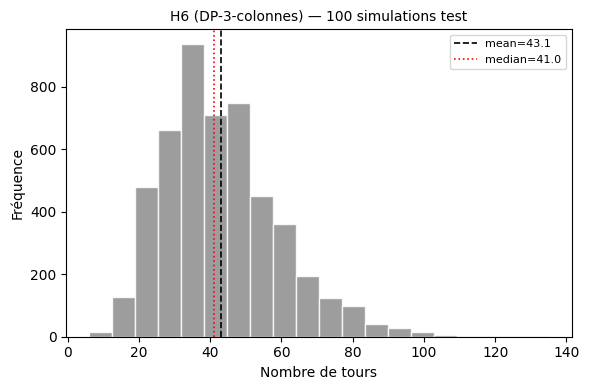

In [ ]:
# ============================================================
# BENCHMARK H6
# ============================================================

N_SIMULATIONS_H6 = 5000

print(f"Lancement H6 sur {N_SIMULATIONS_H6} simulations (test)...")
scores_h6 = []

for i in range(N_SIMULATIONS_H6):
    s = simulate_game(heuristic_dp3)
    scores_h6.append(s)


scores_h6 = np.array(scores_h6)
diverged_h6 = int(np.sum(scores_h6 >= MAX_TURNS))
clean_h6 = scores_h6[scores_h6 < MAX_TURNS]

result_h6 = {
    "mean":     float(np.mean(clean_h6)),
    "std":      float(np.std(clean_h6)),
    "median":   float(np.median(clean_h6)),
    "p10":      float(np.percentile(clean_h6, 10)),
    "p90":      float(np.percentile(clean_h6, 90)),
    "diverged": diverged_h6,
    "scores":   clean_h6,
}

np.save("result_H6_test.npy", clean_h6)
print(f"\nH6 (DP-3-colonnes) : mean={result_h6['mean']:.1f}  median={result_h6['median']:.1f}  p90={result_h6['p90']:.1f}  diverged={diverged_h6}")

# Histogramme H6
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(clean_h6, bins=20, color="#8C8C8C", alpha=0.85, edgecolor="white")
ax.axvline(result_h6["mean"],   color="black", linestyle="--", linewidth=1.2, label=f"mean={result_h6['mean']:.1f}")
ax.axvline(result_h6["median"], color="red",   linestyle=":",  linewidth=1.2, label=f"median={result_h6['median']:.1f}")
ax.set_title("H6 (DP-3-colonnes) — 100 simulations test", fontsize=10)
ax.set_xlabel("Nombre de tours")
ax.set_ylabel("Fréquence")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("benchmark_H6_test.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Résultats

### 5.1 Tableau récapitulatif

In [ ]:
# ============================================================
# RÉSULTATS — tableau 
# ============================================================

# Ajout de H6 dans results pour affichage unifié
results["H6 (DP-3-colonnes)"] = result_h6

print(f"\n{'Heuristique':<28} {'Mean':>7} {'Std':>7} {'Median':>8} {'P10':>6} {'P90':>6} {'Div':>5}")
print("-" * 68)
for name, s in results.items():
    print(
        f"{name:<28} "
        f"{s['mean']:>7.1f} "
        f"{s['std']:>7.1f} "
        f"{s['median']:>8.1f} "
        f"{s['p10']:>6.1f} "
        f"{s['p90']:>6.1f} "
        f"{s['diverged']:>5d}"
    )


Heuristique                     Mean     Std   Median    P10    P90   Div
--------------------------------------------------------------------
Random + Stop@4                341.3   344.5    215.0   87.0  785.8   388
Score@3                         57.6    41.3     47.0   25.0   99.0     0
H1 (min ouvertures)             59.5    40.7     50.0   27.0   99.0     0
H2 (p/restants)                 50.2    34.2     42.0   23.0   85.0     0
H4 (Rule of 28)                 78.1    34.8     72.0   41.0  122.0     0
H5 (Constant Weights)          256.1   210.3    195.0   58.0  538.0     0
H3 (min bust)                   51.4    46.8     41.0   23.0   86.0     0
H6 (DP-3-colonnes)              43.1    16.3     41.0   24.0   65.0     0


### 5.2 Distributions

In [1]:
# ============================================================
# RÉSULTATS — histogrammes sur 2 lignes (avec H6)
# ============================================================

import math
import matplotlib.pyplot as plt

n = len(results)
ncols = math.ceil(n / 2)
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 8), sharey=False)
axes = axes.flatten()

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
          "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]

for ax, (name, s), color in zip(axes, results.items(), colors):
    ax.hist(s["scores"], bins=40, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(s["mean"],   color="black", linestyle="--", linewidth=1.2, label=f"mean={s['mean']:.1f}")
    ax.axvline(s["median"], color="red",   linestyle=":",  linewidth=1.2, label=f"median={s['median']:.1f}")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Nombre de tours")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)

for ax in axes[len(results):]:
    fig.delaxes(ax)

plt.suptitle(
    f"Distribution du nombre de tours pour finir — {N_SIMULATIONS} simulations",
    fontsize=12
)
plt.tight_layout()
plt.savefig("benchmark_heuristics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : benchmark_heuristics.png")

NameError: name 'results' is not defined

Heuristic                          Mean      Std   Median    P10    P90
---------------------------------------------------------------------------
Random + Stop@4                   335.5    335.3    214.0   86.0  763.4
Score@3                            58.3     46.8     47.0   25.0   99.0
H1 (min openings)                  60.7     46.4     50.0   28.0  100.0
H2 (p/remaining)                   50.2     36.7     41.0   23.0   86.0
H3 (min bust)                      51.4     46.8     41.0   23.0   86.0
H4 (Rule of 28)                    23.7      7.1     22.0   16.0   33.0
H5 (Constant Weights)              22.3      7.2     21.0   15.0   32.0
H6 (DP-3-columns - min turns)      17.9      4.5     17.0   13.0   24.0


/tmp/ipykernel_1819/2256449394.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1819/2256449394.py:224: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


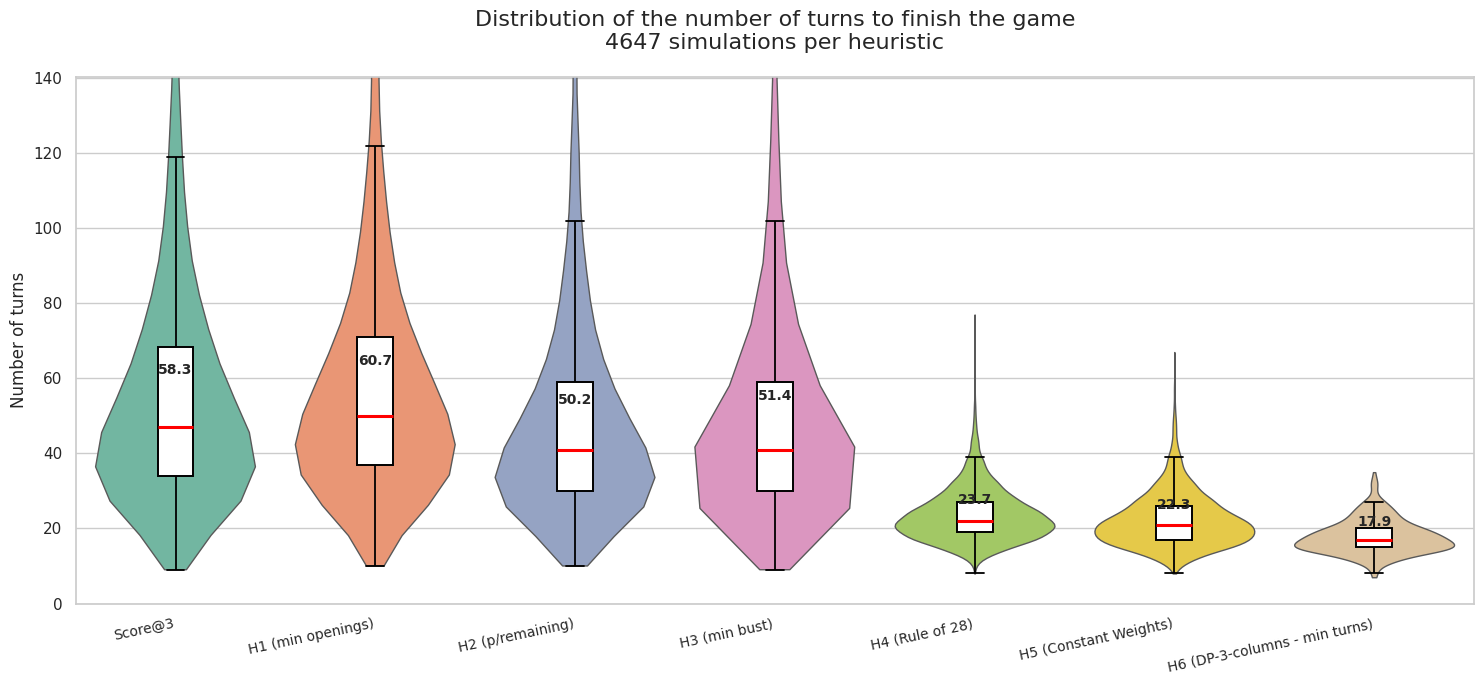


Figure saved: benchmark_heuristics_violin_new.png


In [9]:
# ============================================================
# VIOLIN + BOXPLOTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Loading results
# ------------------------------------------------------------

RESULTS_DIR = "heuristics_opening"

files = {
    "Random + Stop@4":                  "result_Random_+_Stop@4.npy",
    "Score@3":                          "result_Score@3.npy",
    "H1 (min openings)":                "result_H1_min_ouvertures.npy",
    "H2 (p/remaining)":                 "result_H2_p-restants.npy",
    "H3 (min bust)":                    "result_H3.npy",
    "H4 (Rule of 28)":                  "result_H4_Rule_of_28.npy",
    "H5 (Constant Weights)":            "result_H5_Constant_Weights.npy",
    "H6 (DP-3-columns - min turns)":    "result_H7_test.npy",
}

results = {}

for name, filename in files.items():

    path = os.path.join(RESULTS_DIR, filename)

    scores = np.load(path)

    results[name] = {
        "scores": scores,
        "mean": float(np.mean(scores)),
        "median": float(np.median(scores)),
        "std": float(np.std(scores)),
        "p10": float(np.percentile(scores, 10)),
        "p90": float(np.percentile(scores, 90)),
    }

# ------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------

print(
    f"{'Heuristic':30s} "
    f"{'Mean':>8s} {'Std':>8s} {'Median':>8s} "
    f"{'P10':>6s} {'P90':>6s}"
)

print("-" * 75)

for name in files.keys():

    s = results[name]

    print(
        f"{name:30s} "
        f"{s['mean']:8.1f} "
        f"{s['std']:8.1f} "
        f"{s['median']:8.1f} "
        f"{s['p10']:6.1f} "
        f"{s['p90']:6.1f}"
    )

# ------------------------------------------------------------
# Seaborn DataFrame
# ------------------------------------------------------------

rows = []

for name, s in results.items():

    for value in s["scores"]:

        rows.append({
            "Heuristic": name,
            "Turns": value
        })

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Remove Random from plots only
# ------------------------------------------------------------

df_plot = df[df["Heuristic"] != "Random + Stop@4"]

# ------------------------------------------------------------
# Fixed order of heuristics
# ------------------------------------------------------------

order = [
    "Score@3",
    "H1 (min openings)",
    "H2 (p/remaining)",
    "H3 (min bust)",
    "H4 (Rule of 28)",
    "H5 (Constant Weights)",
    "H6 (DP-3-columns - min turns)",
]

# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

palette = sns.color_palette("Set2", len(order))

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 7))

# ------------------------------------------------------------
# Violin plots
# ------------------------------------------------------------

sns.violinplot(
    data=df_plot,
    x="Heuristic",
    y="Turns",
    order=order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=1,
    density_norm="width",
    ax=ax,
)

# ------------------------------------------------------------
# Boxplots
# ------------------------------------------------------------

sns.boxplot(
    data=df_plot,
    x="Heuristic",
    y="Turns",
    order=order,
    width=0.18,
    showcaps=True,
    showfliers=False,
    boxprops=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=1.4
    ),
    whiskerprops=dict(
        linewidth=1.3,
        color="black"
    ),
    capprops=dict(
        linewidth=1.3,
        color="black"
    ),
    medianprops=dict(
        color="red",
        linewidth=2.2
    ),
    ax=ax,
)

# ------------------------------------------------------------
# Smart Y-axis limit
# ------------------------------------------------------------

upper_bounds = []

for name in order:

    q1 = np.percentile(results[name]["scores"], 25)
    q3 = np.percentile(results[name]["scores"], 75)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr

    upper_bounds.append(upper)

ymax = max(upper_bounds) * 1.15

ax.set_ylim(0, ymax)

# ------------------------------------------------------------
# Display means
# ------------------------------------------------------------

for i, name in enumerate(order):

    mean_val = results[name]["mean"]

    ax.text(
        i,
        mean_val + ymax * 0.02,
        f"{mean_val:.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Axes and title
# ------------------------------------------------------------

N_SIMULATIONS = len(next(iter(results.values()))["scores"])

ax.set_title(
    f"Distribution of the number of turns to finish the game\n"
    f"{N_SIMULATIONS} simulations per heuristic",
    fontsize=16,
    pad=20,
)

ax.set_xlabel("")
ax.set_ylabel("Number of turns", fontsize=12)

ax.set_xticklabels(
    order,
    rotation=12,
    ha="right",
    fontsize=10
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.tight_layout()

output_file = "benchmark_heuristics_violin_new.png"

plt.savefig(
    output_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"\nFigure saved: {output_file}")

In [4]:

import os 

RESULTS_DIR = "heuristics_opening"

files = {
    "Random + Stop@4":          "result_Random_+_Stop@4.npy",
    "Score@3":                  "result_Score@3.npy",
    "H1 (min openings)":        "result_H1_min_ouvertures.npy",
    "H2 (p/remaining)":         "result_H2_p-restants.npy",
    "H3 (min bust)":            "result_H3.npy",
    "H4 (Rule of 28)":          "result_H4_Rule_of_28.npy",
    "H5 (Constant Weights)":    "result_H5_Constant_Weights.npy",
    "H6 (DP-3-columns)":        "result_H6_test.npy",
}

results = {}

for name, filename in files.items():

    path = os.path.join(RESULTS_DIR, filename)

    scores = np.load(path)

    results[name] = {
        "scores": scores,
        "mean": float(np.mean(scores)),
        "median": float(np.median(scores)),
        "std": float(np.std(scores)),
        "p10": float(np.percentile(scores, 10)),
        "p90": float(np.percentile(scores, 90)),
    }

# ------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------

print(
    f"{'Heuristic':30s} "
    f"{'Mean':>8s} {'Std':>8s} {'Median':>8s} "
    f"{'P10':>6s} {'P90':>6s}"
)

print("-" * 75)

for name in files.keys():

    s = results[name]

    print(
        f"{name:30s} "
        f"{s['mean']:8.1f} "
        f"{s['std']:8.1f} "
        f"{s['median']:8.1f} "
        f"{s['p10']:6.1f} "
        f"{s['p90']:6.1f}"
    )

Heuristic                          Mean      Std   Median    P10    P90
---------------------------------------------------------------------------
Random + Stop@4                   331.6    331.9    210.0   85.0  750.7
Score@3                            58.9     51.1     47.0   25.0  100.0
H1 (min openings)                  58.8     40.1     50.0   27.0   98.0
H2 (p/remaining)                   50.7     39.5     41.0   23.0   83.0
H3 (min bust)                      51.4     46.8     41.0   23.0   86.0
H4 (Rule of 28)                    78.4     36.3     72.0   40.0  123.0
H5 (Constant Weights)             254.5    205.2    197.0   59.0  519.0
H6 (DP-3-columns)                  43.1     16.3     41.0   24.0   65.0
